In [1]:
import os
RANDOM_STATE = 42
N_JOBS = -1
N_TRIALS = 150

In [2]:
from sklearn.datasets import fetch_kddcup99
import pandas as pd

data = fetch_kddcup99(subset='SA', percent10=True, random_state=RANDOM_STATE)


In [3]:
X_raw = pd.DataFrame(data.data, columns=data.feature_names)
y_raw = pd.Series(data.target)

cat_cols = ['protocol_type', 'service', 'flag']
num_cols = [c for c in X_raw.columns if c not in cat_cols]

for c in cat_cols:
    X_raw[c] = X_raw[c].astype('category')

for c in num_cols:
    X_raw[c] = X_raw[c].astype('float64')

print(X_raw.head(2))
print(X_raw.info())
print(y_raw.value_counts())

   duration protocol_type  service   flag  src_bytes  dst_bytes  land  \
0       0.0        b'tcp'  b'http'  b'SF'      181.0     5450.0   0.0   
1       0.0        b'tcp'  b'http'  b'SF'      239.0      486.0   0.0   

   wrong_fragment  urgent  hot  ...  dst_host_count  dst_host_srv_count  \
0             0.0     0.0  0.0  ...             9.0                 9.0   
1             0.0     0.0  0.0  ...            19.0                19.0   

   dst_host_same_srv_rate  dst_host_diff_srv_rate  \
0                     1.0                     0.0   
1                     1.0                     0.0   

   dst_host_same_src_port_rate  dst_host_srv_diff_host_rate  \
0                         0.11                          0.0   
1                         0.05                          0.0   

   dst_host_serror_rate  dst_host_srv_serror_rate  dst_host_rerror_rate  \
0                   0.0                       0.0                   0.0   
1                   0.0                       0.0     

In [4]:
from sklearn.preprocessing import LabelEncoder

for c in cat_cols:
    X_raw[c] = LabelEncoder().fit_transform(X_raw[c])

#print(X_raw.head(1))

In [5]:
import seaborn as sns

#sns.heatmap(X_raw.corr(), cmap='Blues')

In [6]:
from sklearn.preprocessing import StandardScaler
import numpy as np

target = np.where(y_raw == b'normal.', 1, -1)
print(f"Normali:  {(target == 1).sum()}")
print(f"Attacchi: {(target == -1).sum()}")

X_normal = X_raw[target == 1]

scaler = StandardScaler()
X_train = scaler.fit_transform(X_normal)
X_all   = scaler.transform(X_raw)

print(f"Shape training (solo normali): {X_train.shape}")
print(f"Shape full dataset scalato:    {X_all.shape}")

Normali:  97278
Attacchi: 3377
Shape training (solo normali): (97278, 41)
Shape full dataset scalato:    (100655, 41)


In [7]:
from sklearn.ensemble import IsolationForest
import optuna 
from sklearn.metrics import make_scorer, fbeta_score

scorer = make_scorer(fbeta_score, beta=2)

optuna.logging.set_verbosity(optuna.logging.WARNING)

all_1s = [1 for i in range(len(X_train))]
contamination = 1 / len(X_train)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 400), 
        'max_samples': trial.suggest_float('max_samples', 0.5, 1.0), 
        'max_features': trial.suggest_float('max_features', 0.5, 1.0), 
        #'contamination': trial.suggest_float('contamination', 0.05, 0.25), 
        'contamination': contamination,
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
        'n_jobs': N_JOBS,
        'random_state': RANDOM_STATE
    }

    model = IsolationForest(**params)
    model.fit(X_train)          # solo normali
    preds = model.predict(X_all)  # valuta su tutto il dataset con ground truth
    return fbeta_score(target, preds, beta=2)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
print(study.best_params)

/home/dave/git/CodeAcademy/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Best trial: 141. Best value: 0.994581: 100%|██████████| 150/150 [10:22<00:00,  4.15s/it]

{'n_estimators': 170, 'max_samples': 0.8086722249671194, 'max_features': 0.6320487778538298, 'bootstrap': True}


In [8]:
best_model = IsolationForest(**study.best_params)
best_model.fit(X_train)
pred_all = best_model.predict(X_all)

              precision    recall  f1-score   support

          -1       0.91      0.99      0.94      3377
           1       1.00      1.00      1.00     97278

    accuracy                           1.00    100655
   macro avg       0.95      0.99      0.97    100655
weighted avg       1.00      1.00      1.00    100655



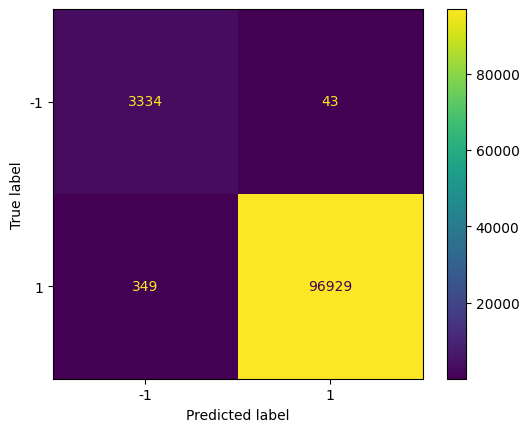

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

print(classification_report(target, pred_all))
ConfusionMatrixDisplay.from_predictions(target, pred_all)
plt.show()
plt.close()